# EDA and Feature Engineering Design

## Objectives

* To explore the data in detail and prepare it for modelling. The main tasks in this file are: 
  * Understand the missingness patterns in the data, while differentiating structural missing observations from random ones.
  * Decide on appropriate imputation approach based on the nature of missingness
  * Where necessary, apply appropriate transformations to the features. For example, using logarithmic transformation for features with a skewed distribution 
  * Convert categorical variables into sets of dummies.   

## Inputs

* `house_prices_records.csv` data located at outputs/datasets/collection

## Outputs

* Conclusions on approaches to take in relation to: 
  * missing data
  * skewed distribution
  * house features
  * multinomial categorical variables
  * outliers

## Imports and Setup

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from feature_engine.encoding import OneHotEncoder
from feature_engine.imputation import MeanMedianImputer
sns.set_style('whitegrid')

## Change Working Directory

We will change the directory to the project level. 

In [2]:
project_root = Path.cwd()
# Move up until we find the project root (identified by a folder/file as marker)
while not (project_root / ".git").exists():
    project_root = project_root.parent

os.chdir(project_root)

print("Working directory set to:", project_root)

Working directory set to: /Users/mehtap/Documents/GitHub/heritage-housing-issues


## Load Data

Load the `house_prices_records` data.

In [3]:
df = pd.read_csv('outputs/datasets/collection/house_prices_records.csv')
df.head()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500
3,961,NaN,NaN,No,216,ALQ,540,NaN,642,Unf,...,60.0,0.0,35,5,7,756,NaN,1915,1970,140000
4,1145,NaN,4.0,Av,655,GLQ,490,0.0,836,RFn,...,84.0,350.0,84,5,8,1145,NaN,2000,2000,250000


## Data Overview

Data has 1,460 observations, with 25 features. The features are a mixture of numerical and categorical indicators: 7 float, 14 integer, and 4 string. Each of these will be examined one by one and necessary transformations will be applied alongside domain-informed new indcator suggestions. 

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   1stFlrSF       1460 non-null   int64  
 1   2ndFlrSF       1374 non-null   float64
 2   BedroomAbvGr   1361 non-null   float64
 3   BsmtExposure   1422 non-null   object 
 4   BsmtFinSF1     1460 non-null   int64  
 5   BsmtFinType1   1315 non-null   object 
 6   BsmtUnfSF      1460 non-null   int64  
 7   EnclosedPorch  136 non-null    float64
 8   GarageArea     1460 non-null   int64  
 9   GarageFinish   1225 non-null   object 
 10  GarageYrBlt    1379 non-null   float64
 11  GrLivArea      1460 non-null   int64  
 12  KitchenQual    1460 non-null   object 
 13  LotArea        1460 non-null   int64  
 14  LotFrontage    1201 non-null   float64
 15  MasVnrArea     1452 non-null   float64
 16  OpenPorchSF    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  OverallQ

In [4]:
df.describe()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtFinSF1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageYrBlt,GrLivArea,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
count,1460.000000,1374.000000,1361.000000,1460.000000,1460.000000,136.000000,1460.000000,1379.000000,1460.000000,1460.000000,1201.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,155.000000,1460.000000,1460.000000,1460.000000
mean,1162.626712,348.524017,2.869214,443.639726,567.240411,25.330882,472.980137,1978.506164,1515.463699,10516.828082,70.049958,103.685262,46.660274,5.575342,6.099315,1057.429452,103.741935,1971.267808,1984.865753,180921.195890
std,386.587738,438.865586,0.820115,456.098091,441.866955,66.684115,213.804841,24.689725,525.480383,9981.264932,24.284752,181.066207,66.256028,1.112799,1.382997,438.705324,135.543152,30.202904,20.645407,79442.502883
min,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1900.000000,334.000000,1300.000000,21.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1872.000000,1950.000000,34900.000000
25%,882.000000,0.000000,2.000000,0.000000,223.000000,0.000000,334.500000,1961.000000,1129.500000,7553.500000,59.000000,0.000000,0.000000,5.000000,5.000000,795.750000,0.000000,1954.000000,1967.000000,129975.000000
50%,1087.000000,0.000000,3.000000,383.500000,477.500000,0.000000,480.000000,1980.000000,1464.000000,9478.500000,69.000000,0.000000,25.000000,5.000000,6.000000,991.500000,0.000000,1973.000000,1994.000000,163000.000000
75%,1391.250000,728.000000,3.000000,712.250000,808.000000,0.000000,576.000000,2002.000000,1776.750000,11601.500000,80.000000,166.000000,68.000000,6.000000,7.000000,1298.250000,182.500000,2000.000000,2004.000000,214000.000000
max,4692.000000,2065.000000,8.000000,5644.000000,2336.000000,286.000000,1418.000000,2010.000000,5642.000000,215245.000000,313.000000,1600.000000,547.000000,9.000000,10.000000,6110.000000,736.000000,2010.000000,2010.000000,755000.000000


## House Sales Price (Target Variable)

In [7]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

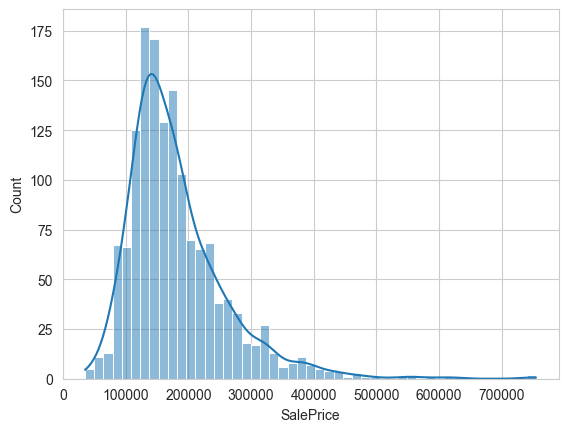

In [8]:
# Histogram of sales price
sns.histplot(df['SalePrice'], kde=True)

In [9]:
# Skewness of Sales Price
df['SalePrice'].skew()

1.8828757597682129

**Findings:**

House prices range from 34,900 to 755,000, with a mean value of 180,921 and a median value of 163,000. The mean is much highe than the median value, suggestive of a right-skewed distribution. 

The visual representation (histogram) and the skewness value of 1.88 confirm this. 

A logarithmic transformation will be considered for this indicator.

### Logarithmic Sales Prices

Below, a visual comparison of `SalePrice` and its logarithmic transformation is provided. While the `SalePrice` is right-skewed, its logarithmic transformation is symmetric. The skweness measure is also closer to zero, with a value of 0.12.

Hence, logarithmic transformation will be applied to this variable. 

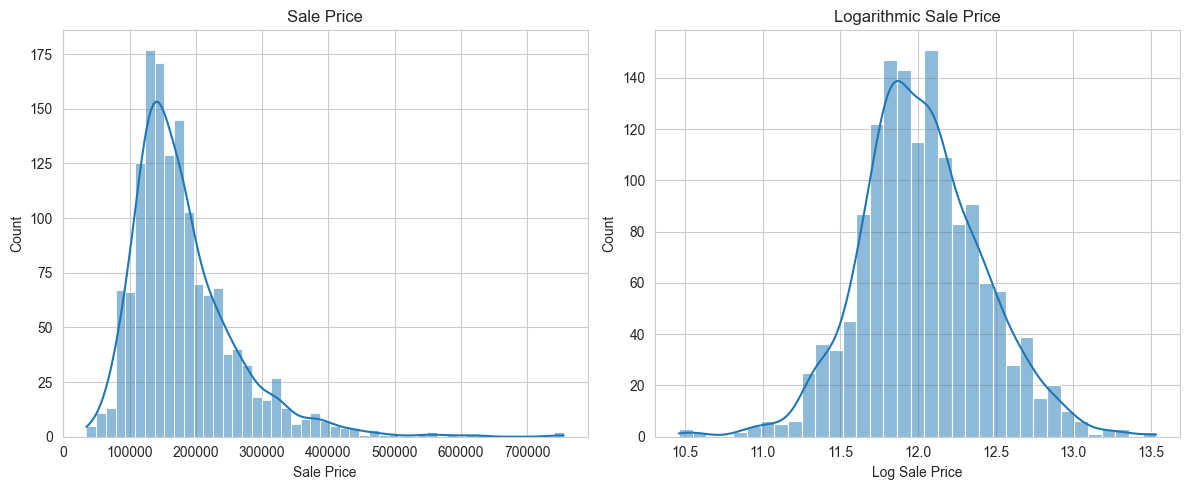

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Raw data distribution
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("Sale Price")
axes[0].set_xlabel("Sale Price")
# Log Distribution
sns.histplot(np.log(df['SalePrice']), kde=True, ax=axes[1])
axes[1].set_title("Logarithmic Sale Price")
axes[1].set_xlabel("Log Sale Price")

plt.tight_layout()
plt.show()

In [11]:
np.log(df['SalePrice']).skew()

0.12133506220520406

## House Features

The data has information on 24 house features. These will be examined one by one to have a proper understanding of their charateristics.  

### Missingness

In [12]:
# Missing counts
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts>0]

EnclosedPorch    1324
WoodDeckSF       1305
LotFrontage       259
GarageFinish      235
BsmtFinType1      145
BedroomAbvGr       99
2ndFlrSF           86
GarageYrBlt        81
BsmtExposure       38
MasVnrArea          8
dtype: int64

In [13]:
# Proportions
missing_percent = (df.isna().mean()*100).sort_values(ascending=False)
missing_percent[missing_percent>0]

EnclosedPorch    90.684932
WoodDeckSF       89.383562
LotFrontage      17.739726
GarageFinish     16.095890
BsmtFinType1      9.931507
BedroomAbvGr      6.780822
2ndFlrSF          5.890411
GarageYrBlt       5.547945
BsmtExposure      2.602740
MasVnrArea        0.547945
dtype: float64

### Living Area Indicators

- `1stFlrSF` : First floor square-feet 
- `2ndFlrSF` : Second floor square-feet 
- `GrLivArea` : Ground living area

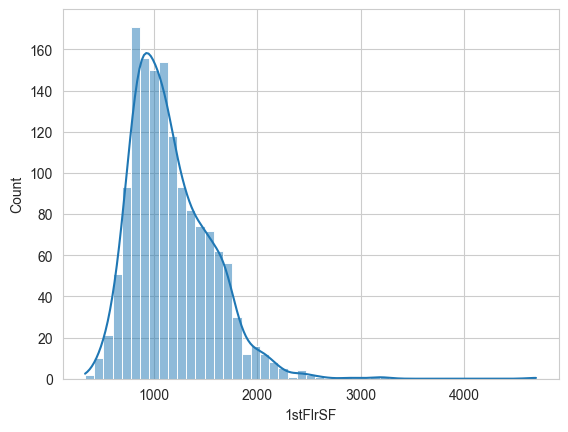

In [14]:
# Check distribution of `1stFlrSF`
for col in ['1stFlrSF']:
  sns.histplot(data=df, x=col, kde=True)
  plt.show()
  print('\n')

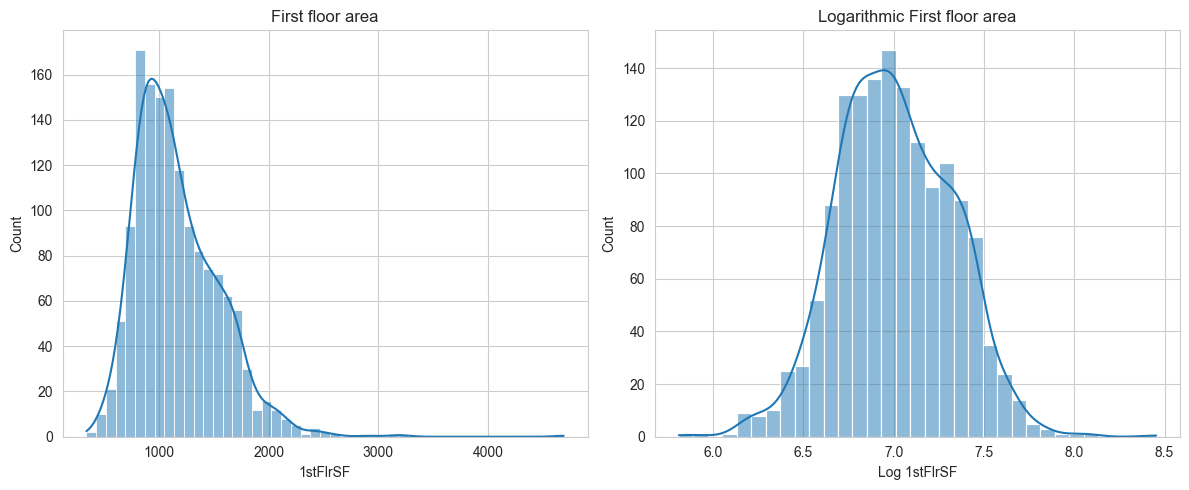

In [15]:
# Compare logarithmic and non-logarithmic distributions of `1stFlrSF`
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Raw data distribution
sns.histplot(df['1stFlrSF'], kde=True, ax=axes[0])
axes[0].set_title("First floor area")
axes[0].set_xlabel("1stFlrSF")
# Log Distribution
sns.histplot(np.log(df['1stFlrSF']), kde=True, ax=axes[1])
axes[1].set_title("Logarithmic First floor area")
axes[1].set_xlabel("Log 1stFlrSF")

plt.tight_layout()
plt.show()

The distribution of `1stFlrSF` becomes more symmetric after the logarithmic transformation.

In [16]:
# Count zero observations in the "2ndFlrSF" column
count_zero = (df["2ndFlrSF"] == 0).sum()
print(count_zero)


781


* Out of 1460 observations, there are 781 zero observations for `2ndFlrSF`. 
* 86 observations has missing values. Considering the context and the high volume of zero observations, these missing observations are very likely to belong to houses where there is no second floor. So, they will be replaced by zero. 
* `GrLivArea` provides information on size of above ground living area. This is likely to be the sum of `1stFlrSF` and `2ndFlrSF`.  
* To confirm this, the missing values of `2ndFlrSF` will be replaced by zero to calculate the total area and to  compare it with the `GrLivArea`. 

In [17]:
# Replace missing values in 2ndFlrSF with 0 and verify the sum of 1stFlrSF and 2ndFlrSF equals GrLivArea
df["2ndFlrSF"].fillna(0, inplace=True)
count_diff = (
    df["1stFlrSF"] + df["2ndFlrSF"] != df["GrLivArea"]
).sum()

print(count_diff)
print(count_diff/len(df))

64
0.043835616438356165


* In 4.4% observations the sum of first and second floor area does not equate to above ground living area size. This is probably because these houses has an additional part that is not included in either of the first or second floor size. 
* While ground living area size is important for house price, having or not having a second floor may also be a determinant. Considering the high volume of zero observations for 2ndFlrSF, a dummy variable for houses that have a second floor together with `GrLivArea` may privide better predictive power. 

In [18]:
# Create a dummy variable for houses with a second floor (2ndFlrSF > 0)
# (missing values already replaced with 0 above)
df["Has2ndFlr"] = (df["2ndFlrSF"] > 0).astype(int)
df["Has2ndFlr"].value_counts()

Has2ndFlr
0    867
1    593
Name: count, dtype: int64

The plot below checks the distirbuton of `GrLivArea`. It is right-skewed. A logarithmic transformation could be applied. 

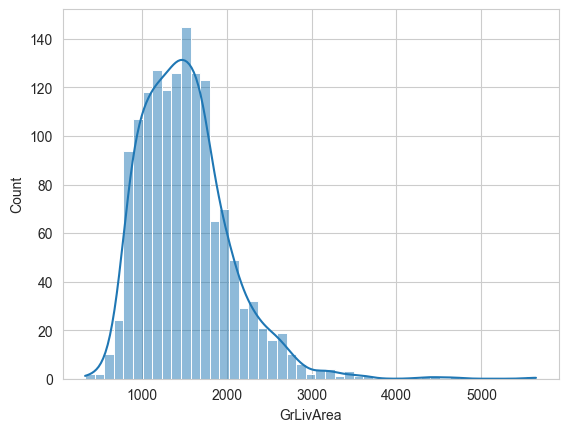

In [19]:
sns.set_style('whitegrid')
for col in ['GrLivArea']:
  sns.histplot(data=df, x=col, kde=True)
  plt.show()
  print('\n')

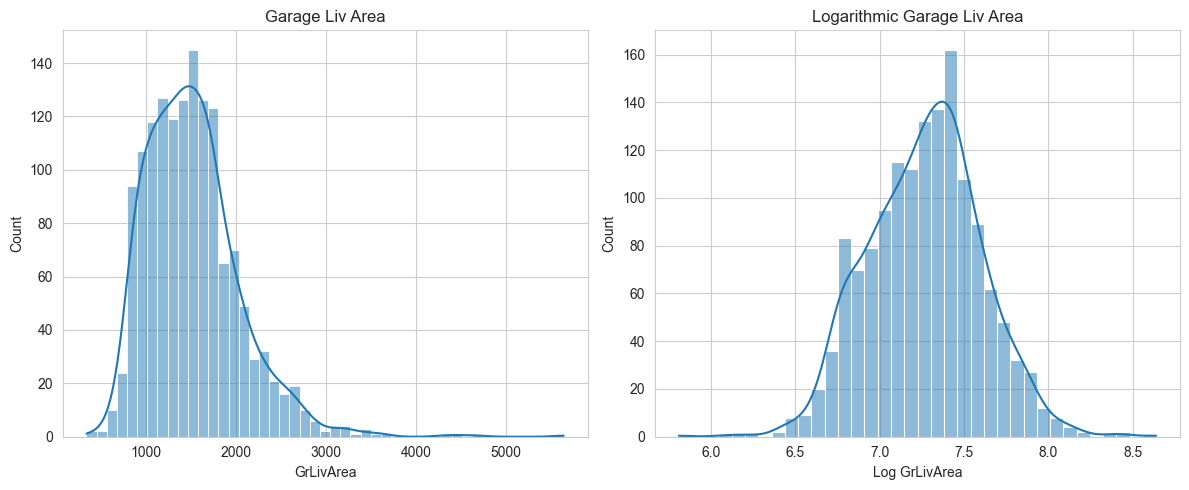

In [20]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Raw data distribution
sns.histplot(df['GrLivArea'], kde=True, ax=axes[0])
axes[0].set_title("Garage Liv Area")
axes[0].set_xlabel("GrLivArea")
# Log Distribution
sns.histplot(np.log(df['GrLivArea']), kde=True, ax=axes[1])
axes[1].set_title("Logarithmic Garage Liv Area")
axes[1].set_xlabel("Log GrLivArea")

plt.tight_layout()
plt.show()


The plots above show the distribution of `GrLivArea` in raw (on the left) and logarithmic (on the right) format. While the raw data is right-skewed, the transformed data is more symmetric. Hence, logarithmic values will be used in modelling. 

The skewness measure calculations below confirm the visual conclusion. 

Further, the Jarque-Bera test reveals that the raw (non-logarithmic) data is not normally distributed while the null hypothesis of normal distribtution cannot be rejected for the logarithmic data (5% significance level; p-value: 0.095). 

In [21]:
# Skewness check
print("Skewness (`GrLivArea`):", df['GrLivArea'].skew()) 
print("Skewness (Log `GrLivArea`):", np.log(df['GrLivArea']).skew())

Skewness (`GrLivArea`): 1.3665603560164552
Skewness (Log `GrLivArea`): -0.006995182187690808


In [22]:
# Jarjue-Bera Test
jb_raw = stats.jarque_bera(df['GrLivArea'].dropna())
jb_log = stats.jarque_bera(np.log(df['GrLivArea'].dropna()))

print("JB on raw data", jb_raw)
print("JB on logarithmic data", jb_log)

JB on raw data SignificanceResult(statistic=1898.7950810202449, pvalue=0.0)
JB on logarithmic data SignificanceResult(statistic=4.697409263480909, pvalue=0.09549278044950565)


Below code inspects a potential pattern for houses where `GrLivArea` is different than the sum of the two floor areas. We see that the difference is always zero or above, suggesting that there is some living space(s) that are not considered in the data.  

In [23]:
df['DiffArea'] = df['GrLivArea'] - (df['1stFlrSF'] + df['2ndFlrSF'])
df['DiffArea'].describe()

count    1460.000000
mean       24.842466
std       131.079171
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      1254.000000
Name: DiffArea, dtype: float64

In [24]:
# Inspect characteristics when DiffArea>0
df[df['DiffArea']>0][['GrLivArea', '1stFlrSF', '2ndFlrSF', 'YearBuilt', 'OverallQual', 'SalePrice']].head(15)

,GrLivArea,1stFlrSF,2ndFlrSF,YearBuilt,OverallQual,SalePrice
3,1717,961,0.0,1915,7,140000
4,2198,1145,0.0,2000,8,250000
51,1176,816,0.0,1934,6,114500
57,1720,860,0.0,2004,7,196500
88,1526,1013,0.0,1915,3,85000
105,1992,1053,0.0,2003,8,250000
108,1517,997,0.0,1919,5,115000
125,754,520,0.0,1935,6,84500
142,1385,910,0.0,1952,5,166000
170,1382,854,0.0,1941,5,128500


The above check does not provide a systematic pattern that hints for a difference or that could be used for analysis. Instead, a dummy variable will be created representing houses where `GrLivArea` is greater than the sum of `1stFlrSF` and `2ndFlrSF`.   

In [25]:
df['HasExtraLivArea'] = (df['DiffArea'] > 0).astype(int)
df['HasExtraLivArea'].value_counts()

HasExtraLivArea
0    1396
1      64
Name: count, dtype: int64

### Bedrooms Above Ground

`BedroomAbvGr`: "Bedrooms above ground (does NOT include basement bedrooms)"


6.8% of observations have missing values for this indicator. These could be because there are no above ground bedrooms in these houses or simply because they are missing. The correlation between first floor SF and this variable is very low (0.12), hence it is difficult to check whether they are genuinely zero or not. The missing values may be imputed by the mean value of this indicator because the distribution is not heavily skewed or by the mode because slightly more than half of observations (51.3%) take the mode value.  

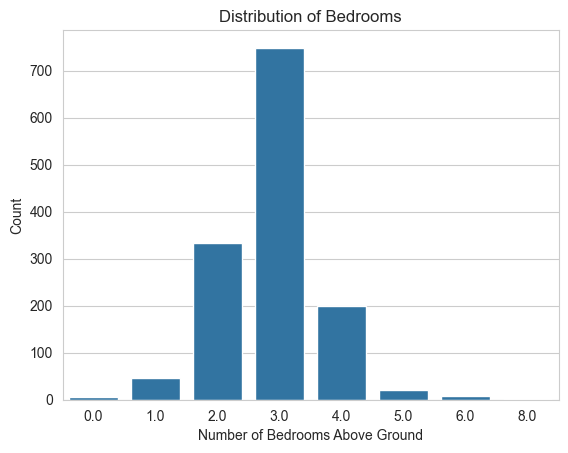

In [26]:
sns.countplot(x='BedroomAbvGr', data=df)

plt.xlabel('Number of Bedrooms Above Ground')
plt.ylabel('Count')
plt.title('Distribution of Bedrooms')
plt.show()

In [27]:
df['BedroomAbvGr'].value_counts(dropna=False)

BedroomAbvGr
3.0    749
2.0    333
4.0    199
NaN     99
1.0     46
5.0     20
6.0      7
0.0      6
8.0      1
Name: count, dtype: int64

In [28]:
# Percentage distribution of values
(df['BedroomAbvGr'].value_counts(dropna=False)/len(df))*100

BedroomAbvGr
3.0    51.301370
2.0    22.808219
4.0    13.630137
NaN     6.780822
1.0     3.150685
5.0     1.369863
6.0     0.479452
0.0     0.410959
8.0     0.068493
Name: count, dtype: float64

In [29]:
df['BedroomAbvGr'].describe()

count    1361.000000
mean        2.869214
std         0.820115
min         0.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         8.000000
Name: BedroomAbvGr, dtype: float64

In [30]:
# Example imputation - replicate with mode in pipelines
mean_val = df['BedroomAbvGr'].mean()
df['BedroomAbvGr'] = df['BedroomAbvGr'].fillna(mean_val)

In [31]:
# Percentage distribution of values after imputation
(df['BedroomAbvGr'].value_counts(dropna=False)/len(df))*100

BedroomAbvGr
3.000000    51.301370
2.000000    22.808219
4.000000    13.630137
2.869214     6.780822
1.000000     3.150685
5.000000     1.369863
6.000000     0.479452
0.000000     0.410959
8.000000     0.068493
Name: count, dtype: float64

### Basement Indicators

- `BsmtExposure` : Refers to walkout or garden level walls (38 observations, corresponding to 2.6% are missing)
- `BsmtFinType1` : Rating of basement finished area (145 observations, corresponding to 9.93% are missing)
- `BsmtFinSF1` : Type 1 finished square-feet
- `BsmtUnfSF` : Unfinished square-feet of basement area
- `TotalBsmtSF` : Total square-feet of basement area

In [32]:
# Cross-tabulation of missing BsmtExposure and TotalBsmtSF==0
pd.crosstab(df['BsmtExposure'].isna(), df['TotalBsmtSF']==0)

TotalBsmtSF,False,True
BsmtExposure,,
False,1422,0
True,1,37


In [33]:
# Percentage distribution of values
(df['BsmtExposure'].value_counts(dropna=False)/df.shape[0])*100

BsmtExposure
No     65.273973
Av     15.136986
Gd      9.178082
Mn      7.808219
NaN     2.602740
Name: count, dtype: float64

- The cross-tabulation of missing `BsmtExposure` and `TotalBsmtSF`==0 indicates that almost all missing `BsmtExposure` values also have a zero `TotalBsmtSF`, implying there is no basement. There is one missing observations where the basement SF is non-zero. In this case, there is likely to be a basement, with no exposure. 
- These missings will be coded as "No_Basement" when `TotalBsmtSF`==0 and as "No" (no exposure) when `TotalBsmtSF`> 0. 

In [34]:
# No basement if TotalBsmtSF==0
df.loc[(df['BsmtExposure'].isna()) & (df['TotalBsmtSF'] == 0), 'BsmtExposure'] = 'No_Basement'

# Has basement but missing exposure if TotalBsmtSF > 0
df.loc[(df['BsmtExposure'].isna()) & (df['TotalBsmtSF'] > 0), 'BsmtExposure'] = 'No'

In [35]:
# Percentage distribution of values after imputation
(df['BsmtExposure'].value_counts(dropna=False)/df.shape[0])*100

BsmtExposure
No             65.342466
Av             15.136986
Gd              9.178082
Mn              7.808219
No_Basement     2.534247
Name: count, dtype: float64

In [36]:
# Confirm no missingness
df['BsmtExposure'].isna().sum()

0

The next variable to be explored is `BsmtFinType1`. It has more missing values than `BsmtExposure`. Below code performs checks for the following:

- whether the `BsmtFinType1` is missing because there is no basement in the house. This can be checked using `TotalBsmtSF` variable. If the total basement area is zero, we can conclude that there is no basement. There are 37 such observations. 
- whether the missing observations are because the basement is unfinished (positive unfinished value, while the finished SF is zero).
- whether there is some kind of a pattern between the `BsmtExposure` and `BsmtFinType1` variables that could hint any reason for missing observations. The cross-tabulation of these two variables does not reveal an obvious pattern. After identifying the structural missingness in the two above points, the remaining ones are likely to be random. They will be labelled as missing. 

In [37]:
df['BsmtFinType1'].value_counts(dropna=False)

BsmtFinType1
Unf    396
GLQ    385
ALQ    202
NaN    145
BLQ    136
Rec    126
LwQ     70
Name: count, dtype: int64

In [38]:
pd.crosstab(df['BsmtFinType1'].isna(), df['TotalBsmtSF']==0)

TotalBsmtSF,False,True
BsmtFinType1,,
False,1315,0
True,108,37


In [39]:
# Impute: No basement if TotalBsmtSF==0
df.loc[(df['BsmtFinType1'].isna()) & (df['TotalBsmtSF'] == 0), 'BsmtFinType1'] = 'No_Basement'

In [40]:
# Check if missing BsmtFinType1 corresponds to cases where BsmtUnfSF>0 and BsmtFinSF1==0
pd.crosstab(df['BsmtFinType1'].isna(), (df['BsmtUnfSF'] > 0) & (df['BsmtFinSF1'] == 0))

col_0,False,True
BsmtFinType1,,
False,956,396
True,74,34


In [41]:
# Impute: Unf (Unfinished) if BsmtUnfSF>0 and BsmtFinSF1==0
df.loc[(df['BsmtFinType1'].isna()) & (df['BsmtUnfSF'] > 0) & (df['BsmtFinSF1'] == 0), 'BsmtFinType1'] = "Unf"

In [42]:
# Remaining missingness after imputation
df['BsmtFinType1'].value_counts(dropna=False)

BsmtFinType1
Unf            430
GLQ            385
ALQ            202
BLQ            136
Rec            126
NaN             74
LwQ             70
No_Basement     37
Name: count, dtype: int64

In [43]:
# Could there be some kind of a pattern in the remaining missingness?
df.loc[df['BsmtFinType1'].isna(),
       ['BsmtExposure', 'BsmtUnfSF', 'BsmtFinSF1', 'TotalBsmtSF']].head(20)

,BsmtExposure,BsmtUnfSF,BsmtFinSF1,TotalBsmtSF
11,No,177,998,1175
26,Mn,180,234,900
55,No,935,490,1425
89,No,402,588,990
95,No,370,310,680
113,Mn,905,35,1809
151,Gd,310,1400,1710
162,Mn,340,1201,1541
196,No,600,1126,1726
197,No,140,1036,1360


In the above output, "No" and "Mn" keeps repeating for the missing `BsmtFinType1` values. the cross-tabulation below checks more accurately if there a systematic relationship between these two. We observe that "No" appears in most cases not only for the missing `BsmtFinType1`, but for all other categories too.   

In [44]:
# Cross-tabulation of BsmtExposure and BsmtFinType1
pd.crosstab(df['BsmtExposure'], df['BsmtFinType1'], dropna=False)

BsmtFinType1,ALQ,BLQ,GLQ,LwQ,No_Basement,Rec,Unf,NaN
BsmtExposure,,,,,,,,
Av,34,15,103,6,0,5,46,12
Gd,16,8,75,8,0,5,11,11
Mn,12,13,33,6,0,13,27,10
No,140,100,174,50,0,103,346,41
No_Basement,0,0,0,0,37,0,0,0


In [45]:
# Replace remaining empty cells as genuine "missing"
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('Missing')

In [46]:
# Check the latest state of the variable
df['BsmtFinType1'].value_counts(dropna=False)

BsmtFinType1
Unf            430
GLQ            385
ALQ            202
BLQ            136
Rec            126
Missing         74
LwQ             70
No_Basement     37
Name: count, dtype: int64

In the model building stage, these missing values could
- be imputed by the mode of the variable
- be included as a separate category of its own. 

Distributions of `BsmtFinSF1`, `BsmtUnfSF`, and `TotalBsmtSF` are provided below. 
- `BsmtFinSF1` : Truncated at zero. Strongly skewed
- `BsmtUnSF` : Also right-skewed
- `TotalBsmtSF` : Right-skewed for non-zero values. Logarithmic transformation makes the distribution of positive values more symmetric. Hence at the modelling stage this variable will be transformed by using log1p (logarithmic transformation after adding one to the values). Use of a `HasBasement` dummy together with this transformed variable will help with avoiding potential bias created by the abundance of zeros.   
- Similarly, creation of `HasBsmtFin` and `HasBsmtUnf` dummies representing positive (non-zero) values of `BsmtFinSF1` and ``BsmtUnSF` may help with the possible zero truncation effects of these variables. 

<Axes: xlabel='BsmtFinSF1', ylabel='Count'>

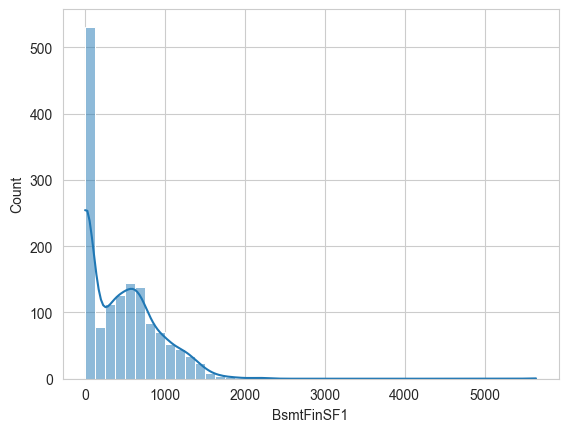

In [47]:
# Histogram of basement finished SF
sns.histplot(df['BsmtFinSF1'], kde=True)

<Axes: xlabel='BsmtUnfSF', ylabel='Count'>

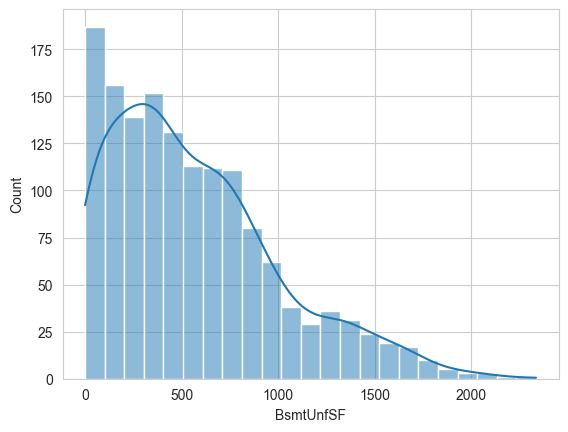

In [48]:
# Histogram of basement unfinished SF
sns.histplot(df['BsmtUnfSF'], kde=True)

<Axes: xlabel='TotalBsmtSF', ylabel='Count'>

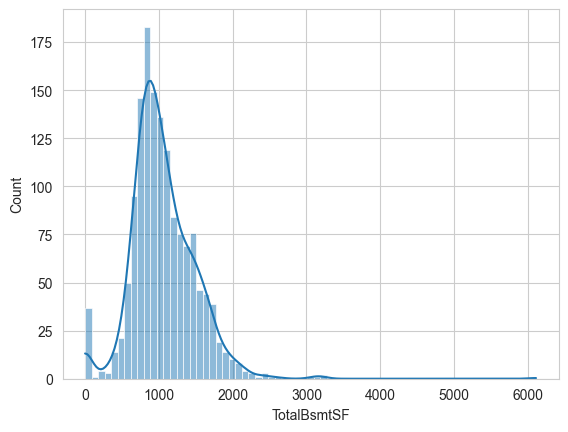

In [49]:
# Histogram of total basement SF
sns.histplot(df['TotalBsmtSF'], kde=True)

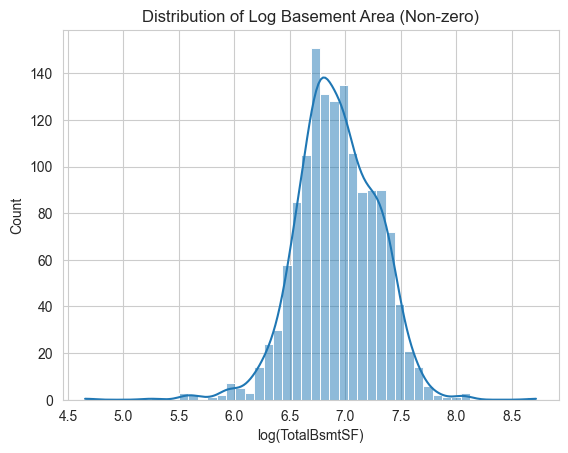

In [50]:
# Histogram of logarithmic total basement SF for non-zero values
NonZeroBsmtSF = df.loc[df['TotalBsmtSF'] > 0, 'TotalBsmtSF']
    
sns.histplot(np.log(NonZeroBsmtSF), kde=True)
plt.xlabel('log(TotalBsmtSF)')
plt.title('Distribution of Log Basement Area (Non-zero)')
plt.show()

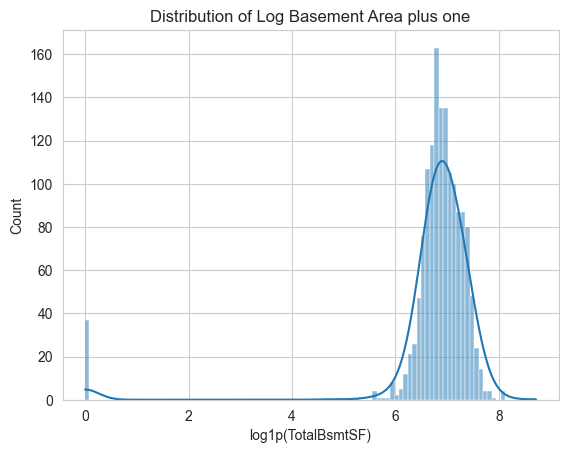

In [51]:
# Histogram of logarithmic total basement SF plus one (to include zero values)
sns.histplot(np.log1p(df['TotalBsmtSF']), kde=True)
plt.xlabel('log1p(TotalBsmtSF)')
plt.title('Distribution of Log Basement Area plus one')
plt.show()

In [52]:
df['HasBasement'] = df['TotalBsmtSF'] > 0
df['HasBasement'].value_counts()

HasBasement
True     1423
False      37
Name: count, dtype: int64

In [53]:
df['HasBasement'] = df['TotalBsmtSF'] > 0
df['HasBasement'].value_counts()

HasBasement
True     1423
False      37
Name: count, dtype: int64

### Garage Features

- `GarageArea` : Size of garage in square-feet
- `GarageFinish` : Interior finish of the garage
- `GarageYrBlt` : Year garage was built

<Axes: xlabel='GarageArea', ylabel='Count'>

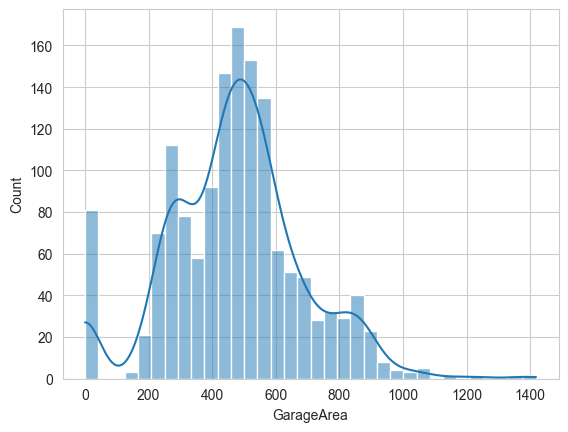

In [54]:
# Distribution of GarageArea
sns.histplot(df['GarageArea'], kde=True)

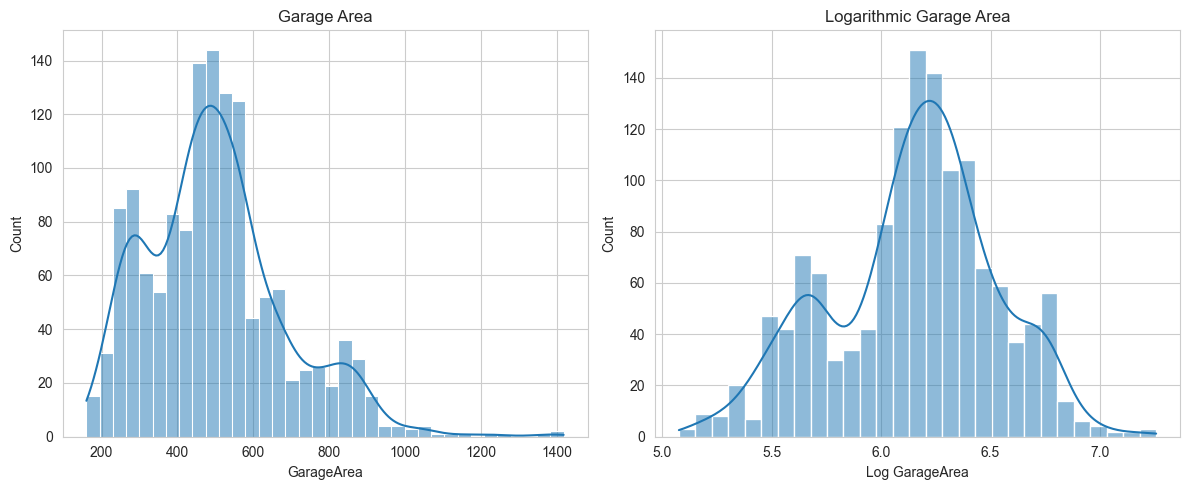

In [55]:
# Distribution of GarageArea for positive values only (w/ and w/o log transformation)
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Raw data distribution
sns.histplot(df[df['GarageArea'] > 0]['GarageArea'], kde=True, ax=axes[0])
axes[0].set_title("Garage Area")
axes[0].set_xlabel("GarageArea")
# Log Distribution
sns.histplot(np.log(df[df['GarageArea'] > 0]['GarageArea']), kde=True, ax=axes[1])
axes[1].set_title("Logarithmic Garage Area")
axes[1].set_xlabel("Log GarageArea")

plt.tight_layout()
plt.show()


In [56]:
print("Skewness (`GarageArea`):", df[df['GarageArea'] > 0]['GarageArea'].skew())
print("Skewness (Log `GarageArea`):", np.log(df[df['GarageArea'] > 0]['GarageArea']).skew())

Skewness (`GarageArea`): 0.8110368967447983
Skewness (Log `GarageArea`): -0.2505408706707518


Distribution of `GarageArea` becomes slightly more symmetric after a logarithmic transformation. Hence a logarithmic transformation will be applied to this indicator. Although, a non-logarithmic version of this variable is worth exploring. 

The zero values of this variable likely refer to cases where there is no garage. Hence a new dummy variable for garage ownership will be created. 

In [57]:
# Create a dummy for garage ownership
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasGarage'].value_counts()

HasGarage
1    1379
0      81
Name: count, dtype: int64

`GarageFinish` indicator (explored below) has 235 missing values, corresponding to around 16% of observations. Some if these missings are likely relates to the house not having a garage.

Missings will be replaced by "No_garage" when `GarageArea`==0 (i.e. when `HasGarage`==0)

It is difficult to speculate on the other missing values. NaN cells will be replaced with "Missing" and a new dummy variable will be created to represent these missing observations. 

In [58]:
df['GarageFinish'].value_counts(dropna=False)

GarageFinish
Unf    546
RFn    366
Fin    313
NaN    235
Name: count, dtype: int64

In [59]:
df.loc[df['HasGarage'] == 0, 'GarageFinish'] = 'No_garage'

In [60]:
df[df['GarageFinish'].isna() == True][[
    'GarageArea', 'GarageYrBlt', 'YearBuilt', 'OverallQual', 'SalePrice']].head(20)

,GarageArea,GarageYrBlt,YearBuilt,OverallQual,SalePrice
7,484,1973.0,1973,7,200000
12,352,1962.0,1962,5,144000
23,572,1976.0,1976,5,129900
27,772,2008.0,2007,8,306000
35,691,2004.0,2004,8,309000
40,440,1965.0,1965,6,160000
41,308,1959.0,1959,5,170000
47,826,2006.0,2006,8,249700
65,852,2004.0,2004,8,317000
104,240,1951.0,1931,7,169500


In [61]:
# Replace remaining empty cells as genuine "missing"
df['GarageFinish'] = df['GarageFinish'].fillna('Missing')

In [62]:
# Create a dummy variable to represent missing observaitions in GarageFinish
df['MissingGarageFinish'] = (df['GarageFinish'] == 'Missing').astype(int)
df['MissingGarageFinish'].value_counts()

MissingGarageFinish
0    1306
1     154
Name: count, dtype: int64

In [63]:
df['GarageFinish'].value_counts(dropna=False)

GarageFinish
Unf          546
RFn          366
Fin          313
Missing      154
No_garage     81
Name: count, dtype: int64

The number of observations (81)n where `GarageArea`==0 (hence `HasGarage`==0) and `GarageYrBlt` are the same, implying that the `GarageYrBlt` is missing when there is no garage. The below code confirms that.  

Replaced missing year cells with a value of zero for modelling purposes (noting that zero is an indicator, but not a true representation of a year)

In [64]:
pd.crosstab(df['HasGarage'], df['GarageYrBlt'].isna())

GarageYrBlt,False,True
HasGarage,,
0,0,81
1,1379,0


In [65]:
df['GarageYrBlt']=df['GarageYrBlt'].fillna(0)

### Kitchen indicators

- `KitchenQual` : Kitchen quality

This indicator does not have any missing values. A set of dummies will be created during modelling stage. 

In [66]:
df['KitchenQual'].value_counts(dropna=False)

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

### Lot Indicators

- `LotArea` : Lot size in square-feet
- `LotFrontage` : Linear feet of street connected to property

- `LotFrontage` has missing cells for 257 observation, corresponding to 17.7% of the observations. These missing cells will be replaced with zero and a dummy variable will be created for missingness. 

In [67]:
df['LotFrontage'].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

<Axes: xlabel='LotFrontage', ylabel='Count'>

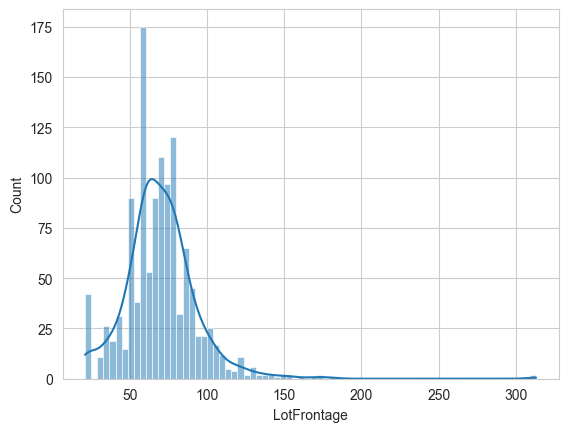

In [68]:
sns.histplot(df['LotFrontage'], kde=True)

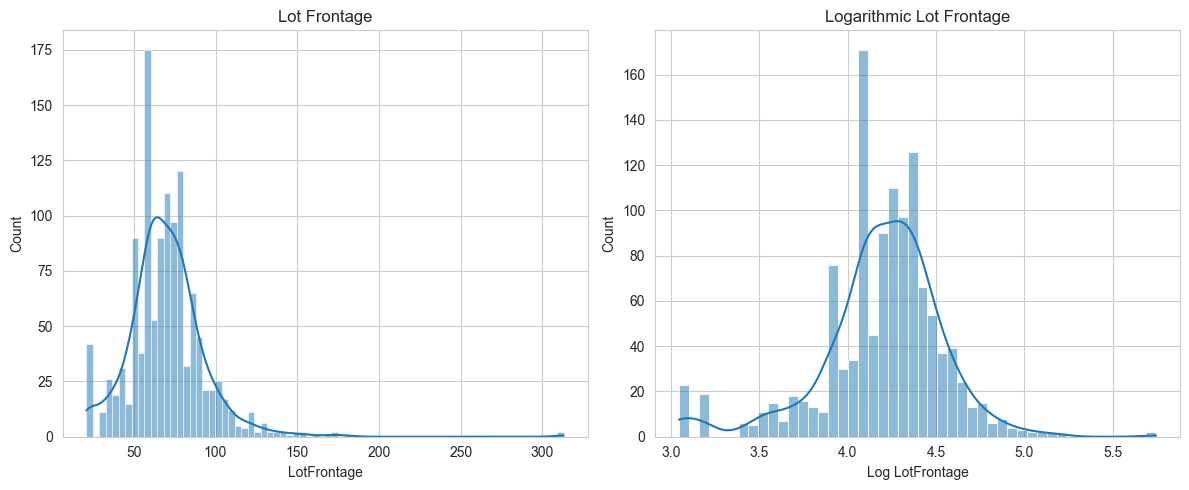

In [69]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Raw data distribution
sns.histplot(df['LotFrontage'], kde=True, ax=axes[0])
axes[0].set_title("Lot Frontage")
axes[0].set_xlabel("LotFrontage")
# Log Distribution
sns.histplot(np.log(df['LotFrontage']), kde=True, ax=axes[1])
axes[1].set_title("Logarithmic Lot Frontage")
axes[1].set_xlabel("Log LotFrontage")

plt.tight_layout()
plt.show()


In [81]:
df['LotFrontage']=df['LotFrontage'].fillna(0)

- `LotArea` indicator clearly has outliers with very high values (creating a heavily right-skewed distribution). In addition to application of a logarithmic transformation, dummy variable will be used for the outliers. 
- The Box-plot below reveals that the log-transformed variable has outliers not only at the higher-end, but also at the lower-end. The distribution of observations between the lower and upper threshold bars on the box plot are fairly symmetric. 
- 1% cut-off from the lower and upper end will be used for creation of the outlier dummies, although this may require further exploration. 

In [70]:
df['LotArea'].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

<Axes: xlabel='LotArea', ylabel='Count'>

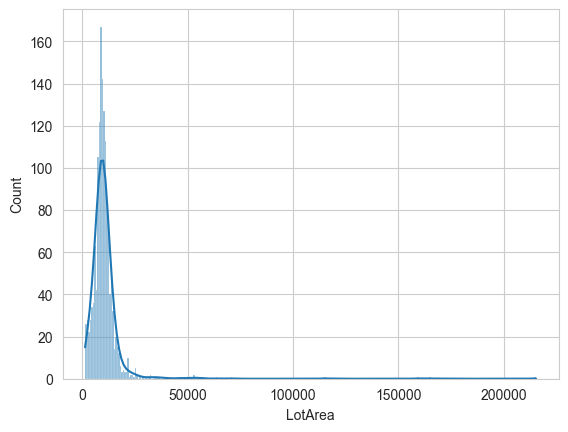

In [71]:
sns.histplot(df['LotArea'], kde=True)

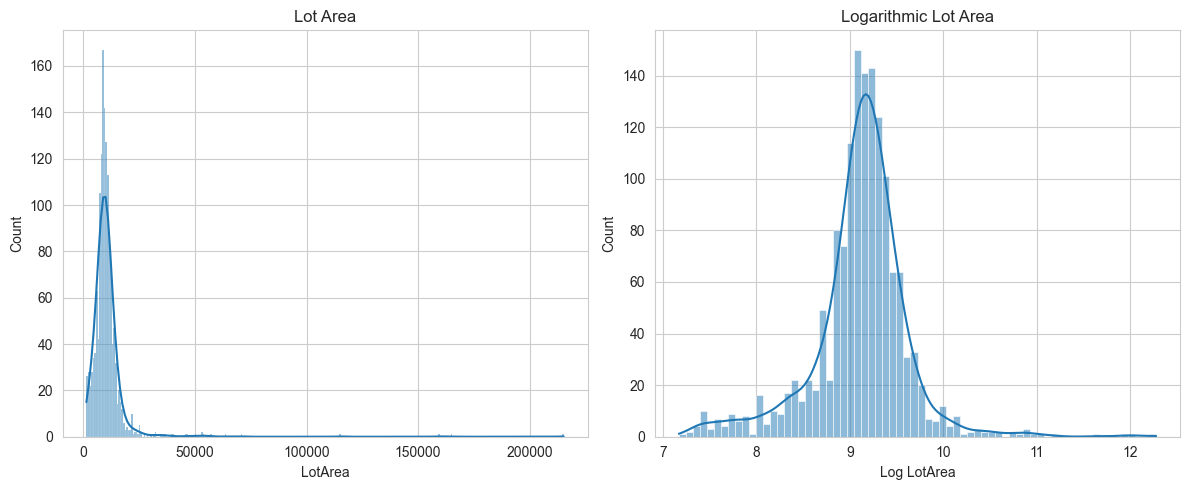

In [72]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Raw data distribution
sns.histplot(df['LotArea'], kde=True, ax=axes[0])
axes[0].set_title("Lot Area")
axes[0].set_xlabel("LotArea")
# Log Distribution
sns.histplot(np.log(df['LotArea']), kde=True, ax=axes[1])
axes[1].set_title("Logarithmic Lot Area")
axes[1].set_xlabel("Log LotArea")

plt.tight_layout()
plt.show()

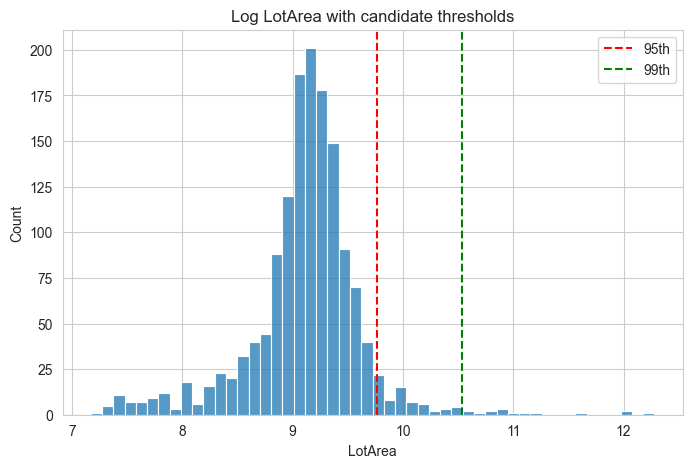

In [73]:
plt.figure(figsize=(8,5))
sns.histplot(np.log(df['LotArea']), bins=50)
plt.axvline(np.log(df['LotArea'].quantile(0.95)), color='red', linestyle='--', label='95th')
plt.axvline(np.log(df['LotArea'].quantile(0.99)), color='green', linestyle='--', label='99th')
plt.legend()
plt.title("Log LotArea with candidate thresholds")
plt.show()

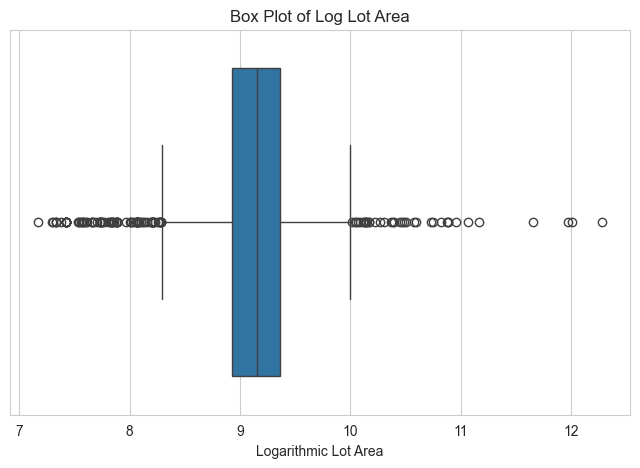

In [74]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=np.log(df['LotArea']))

plt.title("Box Plot of Log Lot Area")
plt.xlabel("Logarithmic Lot Area")
plt.show()

In [77]:
print("Lower threshold, at 1%", np.log(df['LotArea']).quantile(0.01))
print("Lower threshold, at 5%", np.log(df['LotArea']).quantile(0.05))
print("Upper threshold, at 99%", np.log(df['LotArea']).quantile(0.99))
print("Upper threshold, at 95%", np.log(df['LotArea']).quantile(0.95))

Lower threshold, at 1% 7.426549072397305
Lower threshold, at 5% 8.10520066125326
Upper threshold, at 99% 10.533321665784468
Upper threshold, at 95% 9.764291533513635


In [78]:
df['LargeLotArea'] = (df['LotArea'] > df['LotArea'].quantile(0.99)).astype(int)
df['LargeLotArea'].value_counts()

LargeLotArea
0    1445
1      15
Name: count, dtype: int64

In [80]:
df['SmallLotArea'] = (df['LotArea'] < df['LotArea'].quantile(0.01)).astype(int)
df['SmallLotArea'].value_counts()

SmallLotArea
0    1453
1       7
Name: count, dtype: int64

### Masonry Veneer Area

- `MasVnrArea` : Masonry veneer area in square-feet

- The indicator has a lot of zero values and outliers. 
- A dummy variable will be created for zero observations; missing values will be replaced by zero too, with an additional dummy variable to mark them. A logarithmic transformation will be applied to the rest of the values. 

In [82]:
df['MasVnrArea'].describe()

count    1452.000000
mean      103.685262
std       181.066207
min         0.000000
25%         0.000000
50%         0.000000
75%       166.000000
max      1600.000000
Name: MasVnrArea, dtype: float64

<Axes: xlabel='MasVnrArea', ylabel='Count'>

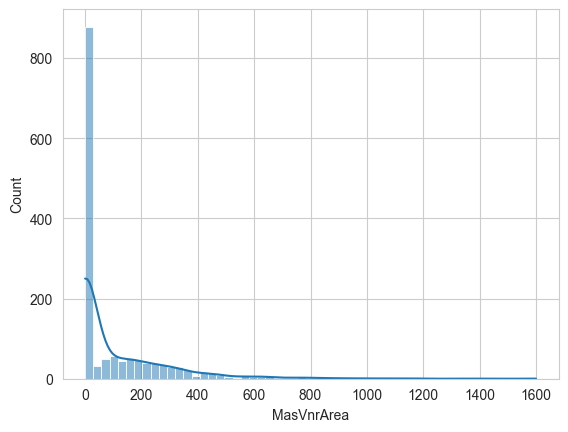

In [83]:
sns.histplot(df['MasVnrArea'], kde=True)

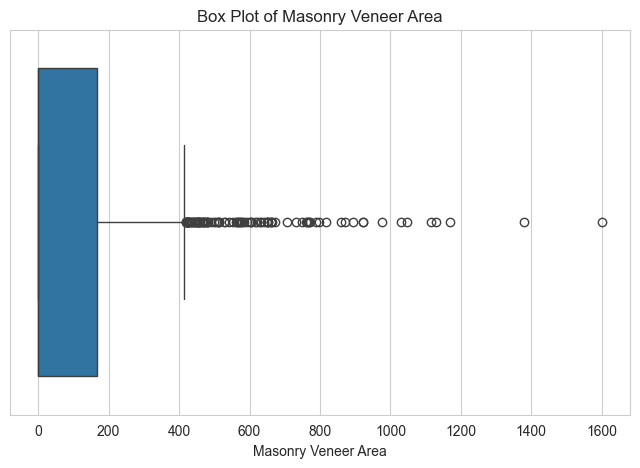

In [85]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['MasVnrArea'])

plt.title("Box Plot of Masonry Veneer Area")
plt.xlabel("Masonry Veneer Area")
plt.show()

In [ ]:
df['MissingMasVnrArea'] = df['MasVnrArea'].isna().astype(int)
df['MasVnrArea']=df['MasVnrArea'].fillna(0)
df['HasMasVnr'] = (df['MasVnrArea'] > 0).astype(int)

### Porch Indicators

- `EnclosedPorch` : Enclosed porch area in square-feet
- `OpenPorchSF` : Open porch area in SF

- There is a high level of missingness for `EnclosedPorch` variable, with around 91% of observations missing. This is likely because of many houses not having an enclosed porch. After replacing missing cells with zero, this variable will be converted into a dummy taking value one when `EnclosedPorch` is positive and zero otherwise.   
- A similar approach will also be applied for open porch: a dummy variable for positive values will be created.
- Bringing information together from these two variables, models will include `TotalPorchSF`, to be calculated as the sum of `EnclosedPorch` and `OpenPorchSF`

In [88]:
df['EnclosedPorch'].describe()

count    136.000000
mean      25.330882
std       66.684115
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      286.000000
Name: EnclosedPorch, dtype: float64

<Axes: xlabel='EnclosedPorch', ylabel='Count'>

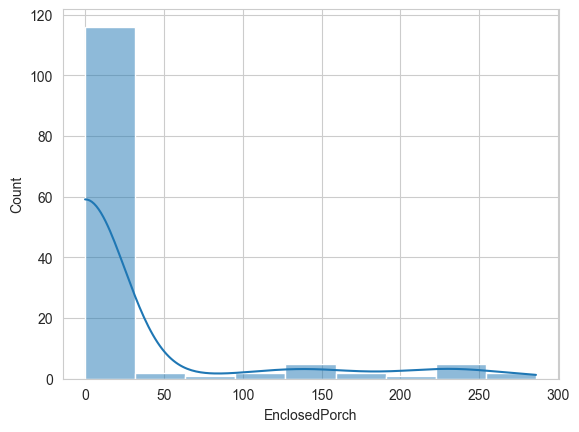

In [89]:
sns.histplot(df['EnclosedPorch'], kde=True)

In [97]:
df['EnclosedPorch']=df['EnclosedPorch'].fillna(0)
df['HasEnclosedPorch'] = (df['EnclosedPorch'] > 0).astype(int)
df['HasEnclosedPorch'].value_counts()   

HasEnclosedPorch
0    1440
1      20
Name: count, dtype: int64

In [92]:
df['OpenPorchSF'].describe()

count    1460.000000
mean       46.660274
std        66.256028
min         0.000000
25%         0.000000
50%        25.000000
75%        68.000000
max       547.000000
Name: OpenPorchSF, dtype: float64

<Axes: xlabel='OpenPorchSF', ylabel='Count'>

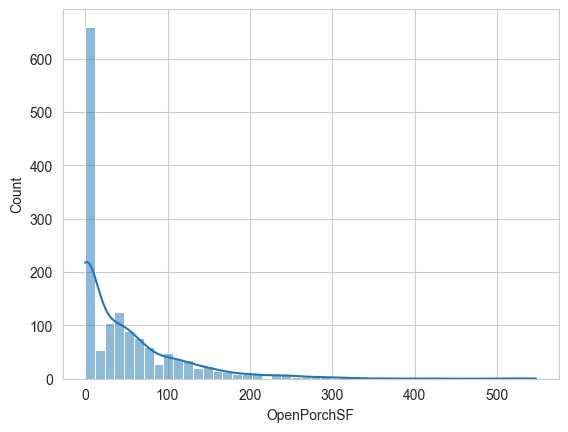

In [93]:
sns.histplot(df['OpenPorchSF'], kde=True)

In [94]:
df['HasOpenPorch'] = (df['OpenPorchSF'] > 0).astype(int)
df['HasOpenPorch'].value_counts()

HasOpenPorch
1    804
0    656
Name: count, dtype: int64

In [96]:
df['TotalPorchSF'] = df['EnclosedPorch'] + df['OpenPorchSF']
df['TotalPorchSF'].describe()

count    136.000000
mean      83.235294
std       89.240021
min        0.000000
25%        0.000000
50%       53.000000
75%      125.750000
max      502.000000
Name: TotalPorchSF, dtype: float64

### Wood Deck Area

- `WoodDeckSF` : Wood deck area in square feet
  
- This indicator also has a lot of missing observations (89%). Similar to what is done with the porch variables, a dummy variable for existence of a wood deck will be created after replacing missing cells with zero value.  

In [98]:
df['WoodDeckSF'].describe()

count    155.000000
mean     103.741935
std      135.543152
min        0.000000
25%        0.000000
50%        0.000000
75%      182.500000
max      736.000000
Name: WoodDeckSF, dtype: float64

In [99]:
df['WoodDeckSF']=df['WoodDeckSF'].fillna(0)
df['HasWoodDeck'] = (df['WoodDeckSF'] > 0).astype(int)
df['HasWoodDeck'].value_counts()

HasWoodDeck
0    1383
1      77
Name: count, dtype: int64

### HouseRatings

- `OverallCond` : Rating of the overall condition of the house
- `OverallQual` : Rating of the overall material and finish of the house

- These variables are measured in 10 point Likert Scale; and hence they are ordinal. A set of dummies representating each potential outcome would be more approriate if the number of options was lower, but considering that these variables are in 10-poin scale, supported by the fact that the values are coded as integer in the data provided, these variables will be treated as numerical during the modelling stage. 

- There are no missing observations. 

- There is more variation in responses in relation to the overall quality of the house while most responses are at point 5 (average) for the overall condition indicator. 

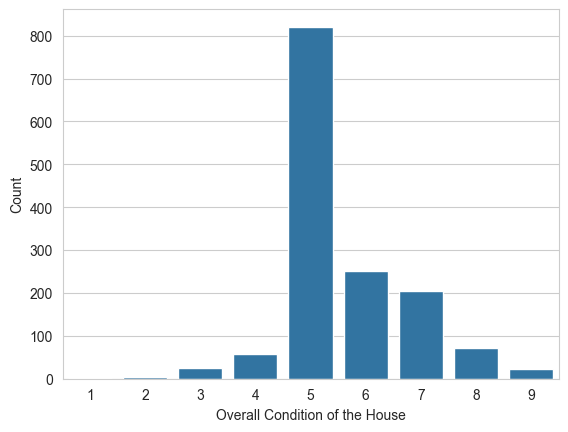

In [7]:
sns.countplot(x='OverallCond', data=df)

plt.xlabel('Overall Condition of the House')
plt.ylabel('Count')
plt.show()

In [5]:
df['OverallCond'].value_counts()

OverallCond
5    821
6    252
7    205
8     72
4     57
3     25
9     22
2      5
1      1
Name: count, dtype: int64

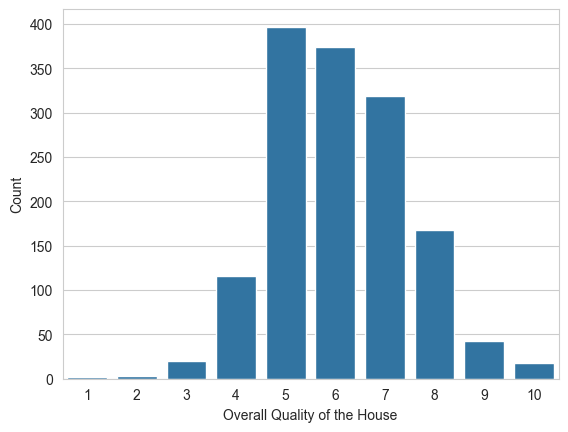

In [8]:
sns.countplot(x='OverallQual', data=df)

plt.xlabel('Overall Quality of the House')
plt.ylabel('Count')
plt.show()

### Year Indicators

- `YearBuilt` : Original construction date
- `YearRemodAdd` : Remodel date (same as construction date if no remodelling or additions)

- There is a large truncation of remodel year at 1950. It appears that no remodelling happened prior to that date, which may be misleading considering the large truncation. There may have been a change at that year in the way the records are kept/recorded or perhaps the correct remodel years were lost for some resaon, only, all to be replaced by 1950. This could be explored further, but for the moemnet, at the modelling stage, the values will be taken as they are given in the data. 

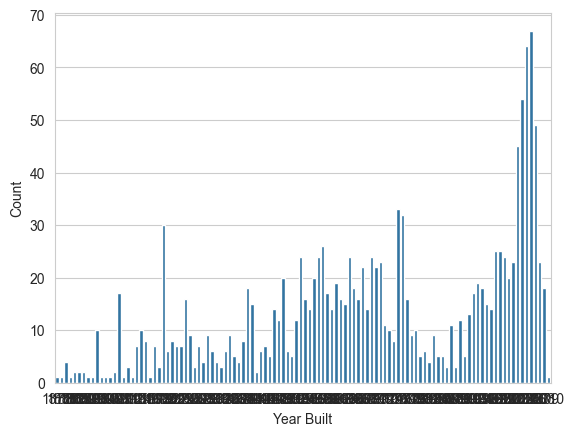

In [9]:
sns.countplot(x='YearBuilt', data=df)

plt.xlabel('Year Built')
plt.ylabel('Count')
plt.show()

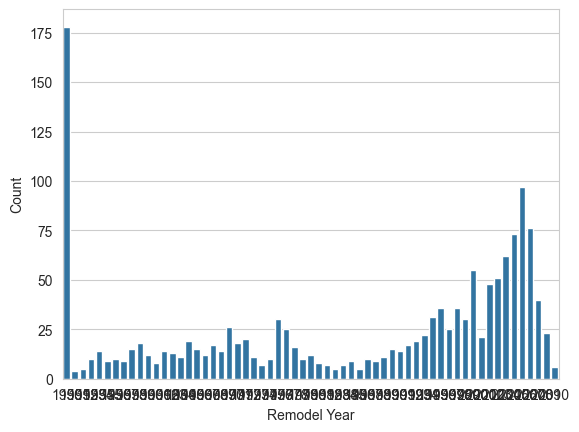

In [11]:
sns.countplot(x='YearRemodAdd', data=df)

plt.xlabel('Remodel Year')
plt.ylabel('Count')
plt.show()

In [12]:
df['YearRemodAdd'].describe()

count    1460.000000
mean     1984.865753
std        20.645407
min      1950.000000
25%      1967.000000
50%      1994.000000
75%      2004.000000
max      2010.000000
Name: YearRemodAdd, dtype: float64

In [13]:
df['YearRemodAdd'].value_counts()

YearRemodAdd
1950    178
2006     97
2007     76
2005     73
2004     62
       ... 
2010      6
1986      5
1952      5
1983      5
1951      4
Name: count, Length: 61, dtype: int64

In [20]:
df.loc[df['YearRemodAdd']==1950, ['YearRemodAdd', 'YearBuilt']].head(20)

,YearRemodAdd,YearBuilt
8,1950,1931
9,1950,1939
21,1950,1930
29,1950,1927
30,1950,1920
51,1950,1934
63,1950,1921
68,1950,1945
74,1950,1915
90,1950,1950


In [21]:
df.loc[df['YearRemodAdd']<1950, ['YearRemodAdd', 'YearBuilt']].head(20)

,YearRemodAdd,YearBuilt


In [ ]:
# Check variaton in remodel year for houses that were built prior to 1950. 
df.loc[df['YearBuilt']<1950, ['YearRemodAdd', 'YearBuilt']].head(20)

,YearRemodAdd,YearBuilt
3,1970,1915
8,1950,1931
9,1950,1939
15,2001,1929
21,1950,1930
29,1950,1927
30,1950,1920
48,2008,1920
51,1950,1934
61,1996,1920


## Conclusions

Based on the exploratory data analysis provided above, this section summarises the key feature engineering steps and data transformations.  


### Logarithmic Transformations


| Variable    | Notes                   |
|-------------|-------------------------|
| `SalePrice` | No missing observations |
| `1stFlrSF`  | No missing observations |
| `GrLivArea` | No missing observations |
| `LotArea`   | No missing observations |


### Logarithmic Transformations After adding One


| Variable      | Notes                                                                          |
|---------------|--------------------------------------------------------------------------------|
| `BsmtFinSF1`  | No missing observations; Complement: `BsmtUnfSF`; Substitute: `TotalBsmtSF`    |
| `BsmtUnfSF`   | No missing observations; Complement: `BsmtFinSF`; Substitute: `TotalBsmtSF`    |
| `TotalBsmtSF` | No missing observations; Substitute: `BsmtFinSF1` and `BsmtUnfSF`              |
| `GarageArea`  | No missing observations                                                        |
| `LotFrontage` | Pre-action: Create `MissingLotFrontage`; Pre-action: replace missing with zero |
| `MasVnrArea`  | Pre-action: Create `MissingMasVnrArea`; Pre-action: Replace missing with zero  |


### Replace missing with zero


| Variable        | Notes                                                                                                 |
|-----------------|-------------------------------------------------------------------------------------------------------|
| `2ndFlrSF`      | Post-action: Create `Has2ndFlr` dummy                                                                 |
| `GarageYrBlt`   | Replace missing with zero; Pre-action: Create `MissingGarageYrBlt`                                    |
| `LotFrontage`   | Replace missing with zero; Pre-action: Create `MissingLotFrontage`; Post-action: Take log1p           |
| `MasVnrArea`    | Replace missing with zero; Pre-action: Create `MissingMasVnrArea`; Post-action: Take log1p            |
| `EnclosedPorch` | Replace missing with zero; Post-action: Create `TotalPorchSF`; Post-action: Create `HasEnclosedPorch` |
| `WoodDeckSF`    | Replace missing with zero; Post-action: Create `HasWoodDeck`                                          |

### Imputation for missing cells (structural missing)

| Variable       | Notes                                                                                                    |
|----------------|----------------------------------------------------------------------------------------------------------|
| `BedroomAbvGr` | Impute with mean; Substutute: Impute with Mode; Pre-action: Create `MissingBedroomAbvGr`                 |
|                | Impute with mode; Substutute: Impute with mean; Pre-action: Create `MissingBedroomAbvGr`                 |
| `BsmtExposure` | Replace missing with "No_basement" if TotalBsmtSf==0                                                     |
|                | Replace remaining missing with "No" if TotalBsmtSF>0; Post-action: Dummyfy                               | 
| `BsmtFinType1` | Replace missing with "No_basement" if TotalBsmtSf==0                                                     |
|                | Replace missing with "Unf" if `BsmtUnfSF>0` & `BsmtFinSF1`==0; Post-action: Create `MissingBsmtFinType1` | 
|                | Replace remaining missing with Mode; Pre-action: Create `MissingBsmtFinType1`                            |
| `GarageFinish` | Replace missing with "No_garage"  if `GarageArea`==0                                                     |
|                | Replace remaining missing with "Missing"; Post-action: Dummyfy                                           | 



### Dummies for Missingness at Random

| Variable       | Variable Created      | Notes                                                                                                               |
|----------------|-----------------------|---------------------------------------------------------------------------------------------------------------------|
| `BedroomAbvGr` | `MissingBedroomAbvGr` | Post-action: Impute with mean; impute with mode                                                                     |
| `BsmtFinType1` | `MissingBsmtFinType1` | Pre-action: Replace structural missings; Post-action: Replace random missings with mode; Post-action: Dummyfy       |
| `LotFrontage`  | `MissingLotFrontage`  | Post-action: Replace missing with zero; Post-action: Take log1p                                                     |
| `MasVnrArea`   | `MissingMasVnrArea`   | Post-action: Replace missing with zero                                                                              |
| `GarageYrBlt`  | `MissingGarageYrBlt`  | Post-action: Replace missing with zero                                                                              |

### Create dummy groups for multinomial variables

| Variable       | Variable Created                  | Notes                        |
|----------------|-----------------------------------|------------------------------|
| `BsmtExposure` | Set of dummies for `BsmtExposure` | Pre-action: Replace missings |
| `BsmtFinType1` | Set of dummies for `BsmtFinType1` | Pre-action: Replace structural missings; Pre-action: Create `MissingBsmtFinType1`; Pre-action: Replace random missings with mode |
| `GarageFinish` | Set of dummies for `GarageFinish` | Pre-action: Replace missings |
| `KitchenQual`  | Set of dummies for `KitchenQual`  |                              |


### Create new feature variable (numerical)

| New Variable   | Description                   | Notes                                                 |
|----------------|-------------------------------|-------------------------------------------------------|
| `TotalPorchSF` | `EnclosedPorch` + `OpenPorch` | Pre-action: Replace missing `EnclosedPorch` with zero |

### Create new feature variable (categorical)

| New Variable       | Description                                             | Notes                                 |
|--------------------|---------------------------------------------------------|---------------------------------------|
| `Has2ndFlr`        | =1 if 2ndFlrSF>0; =0 otherwise                          | Pre-action: Replace missing `2ndFlrSF` with zero|
| `HasExtraLivArea`  | =1 if `GrLivArea` > (`1stFlrSF` + `2ndFlrSF`); =0 otherwise | Pre-action: Replace missing `2ndFlrSF` with zero |  
| `HasBasement`      | =1 if `TotalBsmtSF`>0; =0 otherwise                     |                                       |
| `HasBsmtFin`       | =1 if `BsmtFinSF1`>0; =0 otherwise                      |                                       |
| `HasBsmtUnf`       | =1 if `BsmtUnSF`>0; =0 otherwise                        |                                       |
| `HasGarage`        | =1 if `GarageArea`>0; =0 otherwise                      |                                       |
| `HasLargeLotArea`  | =1 if `LotArea`>`LotArea`.quantile(0.99); =0 otherwise  |                                       |
| `HasSmallLotArea`  | = 1 if `LotArea`<`LotArea`.quantile(0.01); =0 otherwise |                                       |
| `HasMasVnr`        | =1 if MasVnrArea>0; =0 otherwise                        |                                       |
| `HasEnclosedPorch` | =1 if `EnclosedPorch`>0; =0 otherwise                   | Pre-action: Replace missing with zero |
| `HasOpenPorch`     | =1 if `OpenPorchSF`>0; =0 otherwise                     |                                       | 
| `HasWoodDeck`      | =1 if `WoodDeckSF`>0; =0 otherwise                      | Pre-action: Replace missing with zero |
| `BuiltPre1950`     | =1 if `YearBuilt`<1950; =0 otherwise                    |                                       |

### No change variables

| Variable       |
| `OverallCond`  |
| `OverallQual`  |
| `YearBuilt`    |
| `YearRemodAdd` |




## Transformations for Each Indicator

| Variable        | Action                                                            |
|-----------------|-------------------------------------------------------------------|
| `SalePrice`     | Logarithmic transformation                                        |
| `1stFlrSF`      | Logarithmic transformation                                        |
| `2ndFlrSF`      | (1) Replace missing with zero                                     |
|                 | (2) Create `Has2ndFlr`                                            |
|                 | (3) Create `HasExtraLivArea`                                      |
| `GrLivArea`     | Logarithmic transformation                                        |
| `BsmtFinSF1`    | (1) Log1p transformation                                          |
|                 | (2) Create `HasBsmtFin`                                       |  
| `BsmtUnfSF`     | (1) Log1p transformation                                          |
|                 | (2) Create `HasBsmtUnf`                                           | 
| `BsmtFinType1`  | (1) Replace missing with "No_basement" if TotalBsmtSF==0          |
|                 | (2) Replace missing with "Unf" if `BsmtUnfSF>0` & `BsmtFinSF1==0` |
|                 | (3) Create `MissingBsmtFinType1` variable                         |
|                 | (4) Replace remaining missing with mode                           |
|                 | (5) Create set of dummies based on categories                     |
| `BsmtExposure`  | (1) Replace missing with "No_basement" if TotalBsmtSF==0          |
|                 | (2) Replace remaining missing with "No" if TotalBsmtSF>0          | 
|                 | (3) Create set of dummies based on categories                     |
| `TotalBsmtSF`   | (1) Log1p transformation                                          |
|                 | (2) Create `HasBasement`                                          |
| `LotFrontage`   | (1) Create `MissingLotFrontage` variable                          |
|                 | (2) Replace missing with zero                                     |
|                 | (3) Log1p transformation                                          |
| `LotArea`       | (1) Logarithmic transformation                                    |
|                 | (2) Create `HasLargeLotArea`                                      |
|                 | (3) Create `HasSmallLotArea`                                      |
| `BedroomAbvGr`  | (1) Create `MissingBedroomAbvGr` variable                         |
|                 | (2a) Replace missing with mean; Substitute: Impute with mode      |
|                 | (2b) Replace missing with mode; Substitute: Impute with mean      |
| `GarageArea`    | (1) Create `HasGarage`                                            |
|                 | (2) Log1p transformation                                          |
| `GarageFinish`  | (1) Replace missing with "No_garage" if `GarageArea`==0           |
|                 | (2) Replace remaining missing with "Missing"                      |
|                 | (3) Create set of dummies based on categories                     |
| `MasVnrArea`    | (1) Create `MissingMasVnrArea` variable                           |
|                 | (2) Replace missing with zero                                     |
|                 | (3) Log1p transformation                                          |
|                 | (4) Create `HasMasVnr`                                            |
| `GarageYrBlt`   | (1) Create `MissingGarageYrBlt`                                   |
|                 | (2) Replace missing with zero                                     |
| `EnclosedPorch` | (1) Replace missing with zero                                     |
|                 | (2) Create `TotalPorch` = `EnclosedPorch` + `OpenPorchSF`         |
|                 | (3) Create `HasEnclosedPorch`                                     |
| `OpenPorchSF`   | Create `HasOpenPorch`                                             |
| `KitchenQual`   | Create set of dummies based on categories                         |
| `WoodDeckSF`    | (1) Replace missing with zero                                     |
|                 | (2) Create `HasWoodDeck`                                          |
| `OverallCond`   | No change; include as it is provided in data                      |
| `OverallQual`   | No change; include as it is provided in data                      |
| `YearBuilt`     | No change; include as it is provided in data                      |
|                 | Create `BuiltPre1950` for truncation of `YearRemodAdd` at 1950    |
| `YearRemodAdd`  | Include together with `BuiltPre1950`                              |

## Next Steps

Based on the analysis conducted in this notebook and the decisions made about data transformations, the next step will be to create the necessary pipelines for modelling and model evaluation.